In [3]:
import sys
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Add the project root to Python path
project_root = Path(__file__).parent.parent.parent if '__file__' in globals() else Path.cwd().parent.parent
sys.path.append(str(project_root))

# ML toolbox imports
from ml_toolbox.data_loader import DataLoader, create_windows_for_ml, create_label_to_class_map, extract_features_for_ml, FeatureConfig
from ml_toolbox import ButterworthLPF

# Initialize dataset manager
dataset_path = project_root / "data_set_4"
data_loader = DataLoader(dataset_path)

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        random_state=42, 
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2
    ))
])

feat_conf = FeatureConfig(
    features=["ch1_rms", "ch2_rms"],
)

load_params = {
    "classes": None,
    "loads": None,
    "frequencies": None,
    "sensor_types": "current",
    "sample_ids": None,
}
window_params = {
    "window_size": 48000, # 4000 for 2khz dataset
    "overlap_ratio": 0.5,
    "max_windows_per_class": 4975,
    "shuffle": False,
    "random_state": 42,
}

#lpf = ButterworthLPF(cutoff_hz=500, order=4)

data, metadata = data_loader.load_batch(
        classes=load_params["classes"],
        loads=load_params["loads"],
        frequencies=load_params["frequencies"],
        sensor_types=load_params["sensor_types"],
        sample_ids=load_params["sample_ids"],
        preprocessor=None
)

windows, labels, win_metadata = create_windows_for_ml(
        data_list=data,
        metadata_list=metadata,
        window_size=window_params["window_size"],
        overlap_ratio=window_params["overlap_ratio"],
        max_windows_per_class=window_params["max_windows_per_class"],
        shuffle=window_params["shuffle"],
        random_state=window_params["random_state"],
)

features, feature_names = extract_features_for_ml(
        windows,
        metadata_list=win_metadata,
        sensor_type="current",
        feature_config=feat_conf
)


INFO:ml_toolbox.data_loader.data_loader:Loading 64 files with 4 workers
INFO:ml_toolbox.data_loader.data_loader:Successfully loaded 64 files
INFO:ml_toolbox.data_loader.windowing:Class 'd0': selected 1904 of 1904 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd3': selected 1904 of 1904 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd6': selected 1904 of 1904 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd9': selected 1904 of 1904 available windows


In [ ]:

test_path = project_root / "data_set_6_2khz_float32"
test_loader = DataLoader(test_path)

test_feat_conf = FeatureConfig(
    features=["ch3_a2_a1", "ch3_a3_a1", "ch4_a2_a1", "ch4_a3_a1",
              "ch1_a2_a1", "ch1_a3_a1", "ch2_a2_a1", "ch2_a3_a1"],
)

test_data, test_metadata = test_loader.load_batch(
        classes=load_params["classes"],
        loads=load_params["loads"],
        frequencies=load_params["frequencies"],
        sensor_types=load_params["sensor_types"],
        sample_ids=load_params["sample_ids"],
        preprocessor=None
)

test_windows, test_labels, test_win_metadata = create_windows_for_ml(
        data_list=test_data,
        metadata_list=test_metadata,
        window_size=window_params["window_size"],
        overlap_ratio=window_params["overlap_ratio"],
        max_windows_per_class=window_params["max_windows_per_class"],
        shuffle=window_params["shuffle"],
        random_state=window_params["random_state"],
)

test_features, test_feature_names = extract_features_for_ml(
        test_windows,
        metadata_list=test_win_metadata,
        sensor_type="vibration",
        feature_config=test_feat_conf,
)


In [ ]:

pipeline.fit(features, labels)
preds = pipeline.predict(test_features)
score = pipeline.score(test_features, test_labels)
print(f"Test Accuracy: {score:.4f}")

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_labels, preds, labels=pipeline.classes_)
print("Confusion Matrix:")
print(cm)

from sklearn.metrics import f1_score, classification_report

# Расчет F1-score (используем 'macro', если классы сбалансированы)
f1 = f1_score(test_labels, preds, average='macro')
print(f"F1-score (Macro): {f1:.4f}")

# Чтобы увидеть F1 для каждого из 4 классов отдельно:
print("\nDetailed Report:")
print(classification_report(test_labels, preds))


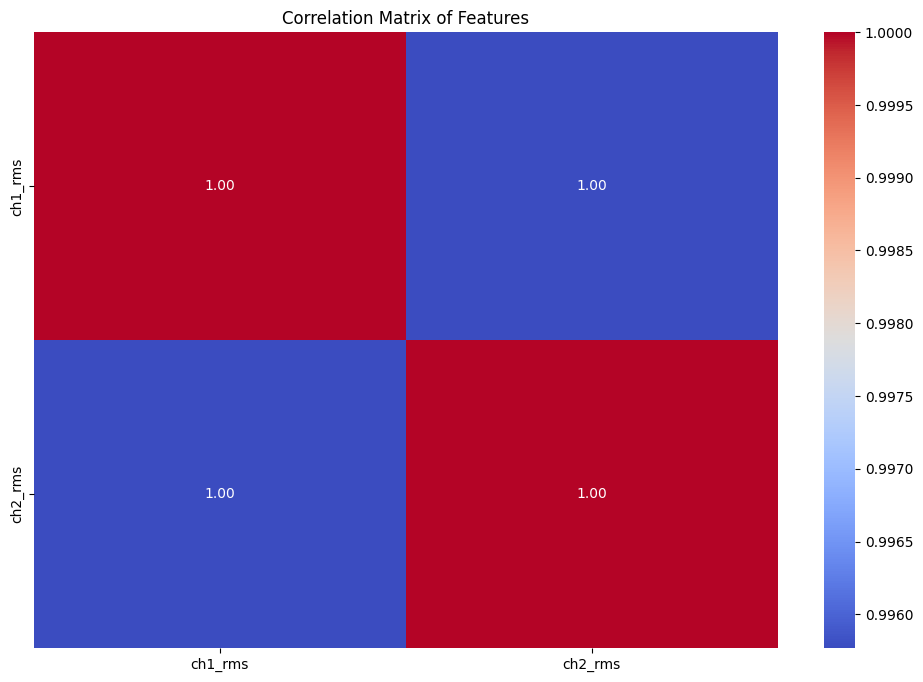

In [4]:
# Correlation Matrix of Features
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert features to a DataFrame
features_df = pd.DataFrame(features, columns=feature_names)

# Calculate the correlation matrix
correlation_matrix = features_df.corr()

# Display the correlation matrix as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Features")
plt.show()


In [ ]:
# Check SHAP values
import shap
explainer = shap.TreeExplainer(pipeline.named_steps['rf'])
shap_values = explainer.shap_values(test_features)


In [ ]:
import numpy as np

# 1. Выбираем класс (например, индекс 1)
class_idx = 3
shap_for_class = shap_values[:, :, class_idx]

# 2. Считаем среднюю важность (mean absolute SHAP) для каждого признака
mean_abs_shap = np.abs(shap_for_class).mean(axis=0)

# 3. Создаем DataFrame для удобной сортировки
feature_importance = pd.DataFrame({
    'feature': test_feature_names,
    'importance': mean_abs_shap
})

# 4. Сортируем и берем топ-5
top_5_features = feature_importance.sort_values(by='importance', ascending=False).head(5)

print(f"Топ-5 важных признаков для класса {class_idx}:")
print(top_5_features)

# 3. Находим индекс самого важного признака
top_feature_idx = np.argmax(mean_abs_shap)
top_feature_name = test_feature_names[top_feature_idx]

print(f"Самый важный признак для класса {class_idx}: {top_feature_name}")

# 1. Создаем объект Explanation для конкретного класса (например, 1)
# Передаем: SHAP-значения класса, данные признаков и их имена
exp = shap.Explanation(
    values=shap_values[:, :, class_idx],      # Срез для нужного класса
    data=test_features,                        # Сами данные (X_test)
    feature_names=test_feature_names           # Имена колонок
)

# 2. Строим scatter plot (он по умолчанию добавит гистограмму сверху)
# Можно передать индекс признака (например, 0) или его имя строкой
shap.plots.scatter(exp[:, "ch4_spectral_spread"])

shap.plots.bar(exp)

shap.plots.beeswarm(exp)

shap.plots.heatmap(exp)

In [5]:
# RMS for external dataset
rms_feat_df = features_df[['ch1_rms', 'ch2_rms']].copy()
meta_df = pd.DataFrame(win_metadata)[['class', 'load', 'electrical_frequency_hz', 'sample_id']].copy()
rms_df = pd.concat([meta_df, rms_feat_df], axis=1)
rms_df = rms_df.sort_values(by=['class', 'load', 'electrical_frequency_hz', 'sample_id']).reset_index(drop=True)
print(rms_df.head())

rms_df.to_excel(project_root / "current_rms_features.xlsx", index=False)

  class  load  electrical_frequency_hz sample_id   ch1_rms   ch2_rms
0    d0   0.0                       20      0001  0.241719  0.246124
1    d0   0.0                       20      0001  0.241066  0.245251
2    d0   0.0                       20      0001  0.242486  0.246700
3    d0   0.0                       20      0001  0.244106  0.248695
4    d0   0.0                       20      0001  0.244899  0.248809


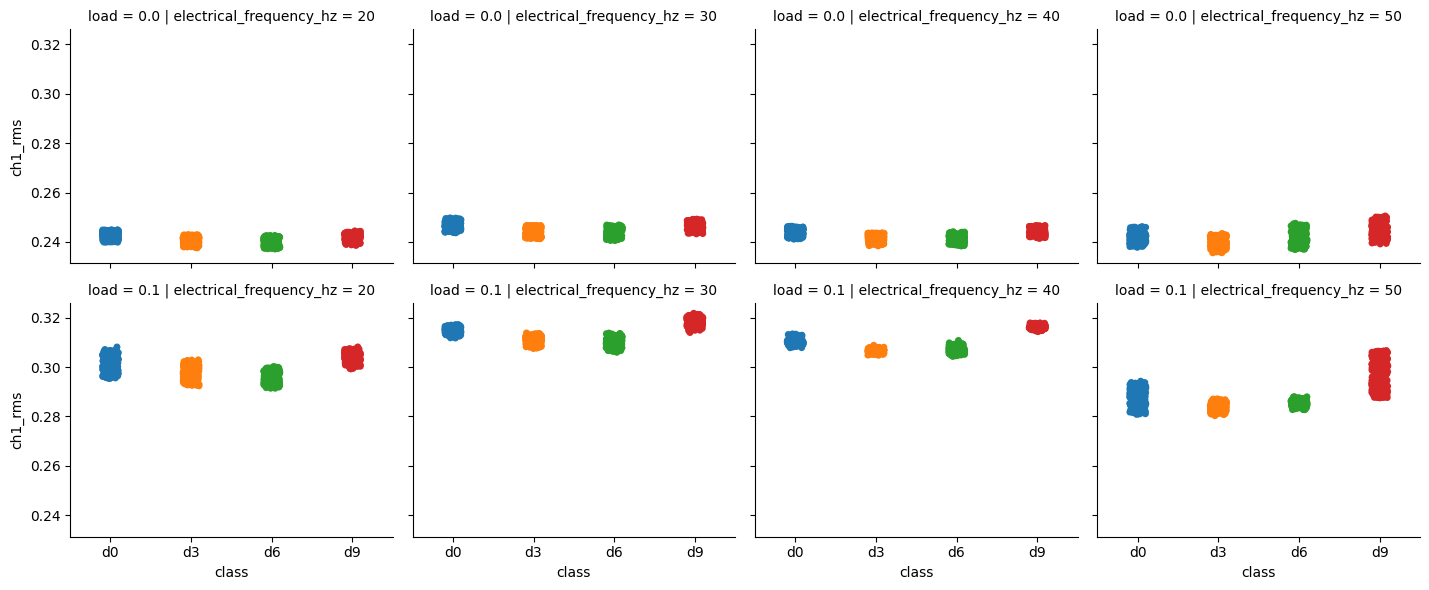

In [6]:
import seaborn as sns
sns.catplot(
    data=rms_df, 
    x='class', 
    y='ch1_rms', 
    col='electrical_frequency_hz', # Speeds across the top
    row='load',                    # Loads down the side
    hue='class', 
    kind='strip',
    height=3,                      # Height of each sub-plot
    aspect=1.2                     # Width vs height ratio
)

In [ ]:

# PCA: colored by motor (dataset) and fault class
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- Combine both datasets ---
all_features = np.vstack([features, test_features])

motor_labels = (
    ["data_set_4"] * len(features) +
    ["data_set_6"] * len(test_features)
)

class_labels = (
    [m["class"] for m in win_metadata] +
    [m["class"] for m in test_win_metadata]
)

# --- Scale on the full combined set ---
scaler_pca = StandardScaler()
all_features_scaled = scaler_pca.fit_transform(all_features)

# --- Fit PCA ---
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(all_features_scaled)
var_explained = pca.explained_variance_ratio_

# --- Plotting helpers ---
motor_labels = np.array(motor_labels)
class_labels = np.array(class_labels)

motor_colors = {"data_set_4": "#2196F3", "data_set_6": "#FF5722"}
class_palette = {"d0": "#4CAF50", "d3": "#FFC107", "d6": "#F44336", "d9": "#9C27B0"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: colored by motor / dataset
for motor, color in motor_colors.items():
    mask = motor_labels == motor
    axes[0].scatter(
        pcs[mask, 0], pcs[mask, 1],
        c=color, label=motor, alpha=0.3, s=5, rasterized=True
    )
axes[0].set_xlabel(f"PC1 ({var_explained[0]*100:.1f}% var)")
axes[0].set_ylabel(f"PC2 ({var_explained[1]*100:.1f}% var)")
axes[0].set_title("PCA — colored by motor (dataset)")
axes[0].legend(markerscale=3, framealpha=0.7)

# Right: colored by fault class
for cls, color in class_palette.items():
    mask = class_labels == cls
    axes[1].scatter(
        pcs[mask, 0], pcs[mask, 1],
        c=color, label=cls, alpha=0.3, s=5, rasterized=True
    )
axes[1].set_xlabel(f"PC1 ({var_explained[0]*100:.1f}% var)")
axes[1].set_ylabel(f"PC2 ({var_explained[1]*100:.1f}% var)")
axes[1].set_title("PCA — colored by fault class")
axes[1].legend(markerscale=3, framealpha=0.7)

fig.suptitle("PCA of vibration features (data_set_4 + data_set_6)", fontsize=13)
plt.tight_layout()
plt.show()
